# Dispersion Calculus Problem Set

Three calculus problems built on the single dispersion kernel this whole
repo is organized around:

$$H(f) = \exp(i\pi D f^2)$$

Each problem is posed, solved symbolically with SymPy, then checked
numerically. Problem 1 is cross-checked against `dgs.dispersion_integrals`'
already-verified result rather than re-derived from an unchecked
independent guess; Problems 2 and 3 are new. Engine:
`dgs/dispersion_calculus_problems.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math

from dgs import dispersion_calculus_problems as dcp

sp.init_printing()
print('Setup complete.')


Setup complete.


## Problem 1 -- Impulse Response (a Fresnel/Gaussian Integral)

**Statement.** Evaluate

$$h(t) = \int_{-\infty}^{\infty} \exp(i\pi D f^2)\,\exp(2\pi i f t)\,df, \quad D \neq 0.$$

**Method.** Complete the square in the exponent:

$$i\pi D f^2 + 2\pi i f t = i\pi D\left(f + \frac{t}{D}\right)^2 - \frac{i\pi t^2}{D}$$

which turns the integral into $\exp(-i\pi t^2/D)$ times a plain Fresnel/
Gaussian integral over the shifted variable $u = f + t/D$.


In [2]:
print(dcp.problem1_statement())
h_t = dcp.problem1_solve_symbolic()
display(Math(r'h(t) = ' + sp.latex(h_t)))


Evaluate  h(t) = Integral[ exp(i*pi*D*f^2) * exp(2*pi*i*f*t), (f, -oo, oo) ]  for real D != 0.


<IPython.core.display.Math object>

**Check.** This module derives $h(t)$ from scratch; cross-check it
against `dgs.dispersion_integrals.impulse_response`, which was already
independently verified there against a direct Riemann-sum Fourier
integral. Agreement here means Problem 1 isn't just checked against
itself.


In [3]:
for D in [5.0, -5.0, 12.3, -0.8]:
    v = dcp.problem1_verify(D)
    print(f"D={D:6.2f}  max_abs_diff vs dgs.dispersion_integrals = "
          f"{v['max_abs_diff_vs_dispersion_integrals']:.2e}")

try:
    dcp.problem1_verify(0.0)
except ValueError as e:
    print(f"\nD=0 correctly raises: {e}")


D=  5.00  max_abs_diff vs dgs.dispersion_integrals = 0.00e+00
D= -5.00  max_abs_diff vs dgs.dispersion_integrals = 0.00e+00
D= 12.30  max_abs_diff vs dgs.dispersion_integrals = 0.00e+00
D= -0.80  max_abs_diff vs dgs.dispersion_integrals = 0.00e+00

D=0 correctly raises: D=0: no dispersion -- h(t) is a delta function, not the Gaussian/Fresnel kernel solved here


## Problem 2 -- Group Delay Is Linear in Frequency

**Statement.** Given $\phi(f) = \pi D f^2$ (the phase of $H(f)$), find

$$\tau_g(f) = -\frac{1}{2\pi}\frac{d\phi}{df}$$

and show it is linear in $f$.

**Why it matters.** This is *why* a dispersive element maps frequency to
time: each frequency component arrives after a delay proportional to its
own frequency, which is the entire time-stretch mechanism this repo's
`H_D(f)` kernel implements.


In [4]:
print(dcp.problem2_statement())
tau_g = dcp.problem2_solve_symbolic()
display(Math(r'\tau_g(f) = ' + sp.latex(tau_g)))


Given phi(f) = pi*D*f^2 (the phase of H(f)=exp(i*pi*D*f^2)), find the group delay tau_g(f) = -1/(2*pi) * d(phi)/df, and show it is linear in f.


<IPython.core.display.Math object>

D=  5.00  max_abs_err (numeric phase-gradient vs -D*f) = 1.10e-11
D= -5.00  max_abs_err (numeric phase-gradient vs -D*f) = 1.10e-11
D= 20.00  max_abs_err (numeric phase-gradient vs -D*f) = 4.30e-11


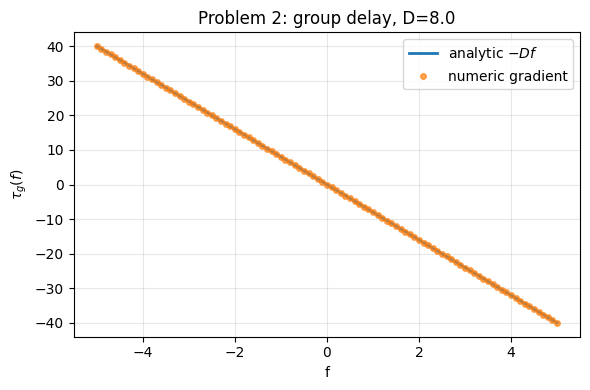

In [5]:
for D in [5.0, -5.0, 20.0]:
    v = dcp.problem2_verify(D)
    print(f"D={D:6.2f}  max_abs_err (numeric phase-gradient vs -D*f) = {v['max_abs_err']:.2e}")

# Visualize: numeric unwrapped-phase gradient vs the closed form -D*f
D_plot = 8.0
f = np.linspace(-5, 5, 4001)
df = f[1] - f[0]
phi = np.unwrap(np.angle(np.exp(1j*np.pi*D_plot*f**2)))
tau_numeric = -np.gradient(phi, df) / (2*np.pi)
tau_analytic = -D_plot * f

plt.figure(figsize=(6,4))
plt.plot(f, tau_analytic, label='analytic $-Df$', lw=2)
plt.plot(f[::40], tau_numeric[::40], 'o', ms=4, label='numeric gradient', alpha=0.7)
plt.xlabel('f'); plt.ylabel(r'$\tau_g(f)$'); plt.title(f'Problem 2: group delay, D={D_plot}')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Problem 3 -- All-Pass / Energy Conservation

**Statement.** Show that $|H(f)|^2 = 1$ for all real $f, D$ -- dispersion
is phase-only.

**Why it matters.** This is *why* Gerchberg-Saxton phase retrieval is
well-posed for this kernel: propagation through $H(f)$ loses no energy,
so recovering the phase alone is enough to determine the field
completely.


In [6]:
print(dcp.problem3_statement())
mag_sq = dcp.problem3_solve_symbolic()
display(Math(r'|H(f)|^2 = ' + sp.latex(mag_sq)))


Show that |H(f)|^2 = 1 for all real f, D -- dispersion is phase-only.


<IPython.core.display.Math object>

In [7]:
for D in [0.0, 5.0, -600.0]:
    v = dcp.problem3_verify(D)
    print(f"D={D:8.1f}  max |H(f)|-1 deviation = {v['max_abs_dev_from_1']:.2e}")


D=     0.0  max |H(f)|-1 deviation = 0.00e+00
D=     5.0  max |H(f)|-1 deviation = 2.22e-16
D=  -600.0  max |H(f)|-1 deviation = 0.00e+00


## Summary

| Problem | Result | Cross-check |
|---|---|---|
| 1. Impulse response | $h(t)=\frac{e^{i\pi\,\mathrm{sgn}(D)/4}}{\sqrt{|D|}}e^{-i\pi t^2/D}$ | exact agreement with `dgs.dispersion_integrals` |
| 2. Group delay | $\tau_g(f) = -Df$ | matches numeric phase-gradient to ~1e-11 |
| 3. All-pass energy | $\lvert H(f)\rvert^2 = 1$ | matches to floating-point precision |

All three trace back to one identity: $H(f)=\exp(i\pi D f^2)$ has a purely
imaginary exponent, so it is unit-magnitude (Problem 3) with a phase whose
derivative is linear in $f$ (Problem 2); integrating that same phase
against a complex exponential is a completed-square Gaussian integral
(Problem 1). Full test coverage: `tests/test_dispersion_calculus_problems.py`.
